### **Exemplo - Exercício 6**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def metodo_iqr(data: pd.DataFrame, column: str) -> pd.DataFrame:

    arr = data[column]

    Q3 = arr.quantile(0.75)
    Q1 = arr.quantile(0.25)

    IQR = Q3 - Q1

    lim_sup = Q3 + 1.5 * IQR
    lim_inf = Q1 - 1.5 * IQR

    intervalo = ((arr < lim_inf) | (arr > lim_sup))

    outliers = arr[intervalo]

    return outliers


In [3]:
df = pd.DataFrame({
    "idade": [
        20, 21, 22, 23, 24, 25, 26, 27, 28, 29,
        30, 31, 32, 33, 34, 35, 36, 37, 38, 39,
        100, 120, -10
    ]
})

df.head()

,idade
0,20
1,21
2,22
3,23
4,24


#### **Teste - Método IQR**

In [4]:
outliers = metodo_iqr(data=df, column='idade')

print(f"-------------- Outliers --------------\n")
display(outliers)

-------------- Outliers --------------



20    100
21    120
22    -10
Name: idade, dtype: int64

#### **Visualização - BoxPlot**

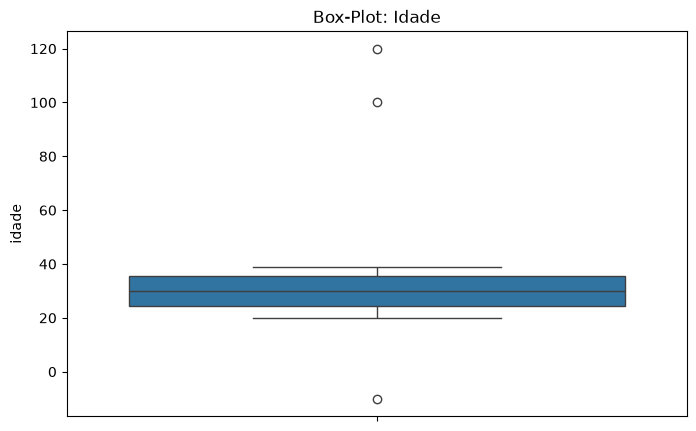

In [5]:
plt.figure(figsize=(8,5))
plt.title("Box-Plot: Idade")
sns.boxplot(data=df['idade'])
plt.show()

#### **Teste - Método do desvio padrão**

In [6]:
def metodo_desvio_padrao(data: pd.DataFrame, column: str) -> pd.DataFrame:

    arr = data[column]

    desvio_padrao = arr.std()
    media = arr.mean()

    intervalo = ((arr < media - 3 * desvio_padrao) | (arr > media + 3 * desvio_padrao))

    outliers = arr[intervalo]

    return outliers

In [7]:
outliers = metodo_desvio_padrao(data=df, column='idade')

print(f"-------------- Outliers --------------\n")
display(outliers)

-------------- Outliers --------------



21    120
Name: idade, dtype: int64